# Random rollout on CartPole

This notebook shows the smallest end-to-end loop: build a **vector** environment from `EnvConfig`, sample random actions, and watch the rollout as an animated GIF.

## What mouse-env does

Most Gymnasium environments are **episodic**: an agent acts until termination or truncation, then the caller must call `reset()` before the next episode can begin. That interface works well when each episode is an independent sample. It becomes awkward when the experiment is about behavior *across* multiple episodes — where what an agent learns or observes in one episode should influence the next.

**mouse-env** converts episodic Gymnasium environments into **continuing environments**. You call `step()` in a loop, forever. When an episode ends, mouse-env resets the underlying environment internally and emits the first observation of the next episode on the very next step — no public `reset()` call required, no special handling needed at the episode boundary.

Three design decisions make this more than a thin wrapper:

- **Reset frames are first-class outputs.** The reset observation appears in the same `outputs` record shape as every other step, with `time=0`, `done=0`, and the configured `reset_reward`. Training code sees a uniform stream.
- **Episode structure stays visible.** The `done` field uses integer codes so transitions, truncations, and reset frames are all distinguishable: `0` = running, `1` = terminated (Gymnasium `terminated=True`), `2` = truncated (Gymnasium `truncated=True`). Reset frames always emit `done=0`.
- **Rewards are shaped at step time.** `reward_scale` and `reward_shift` apply a linear transform to each per-step reward. Raw cumulative episode returns are separately tracked in `env.tracker`.

## Outputs and the metrics tracker

Every `step()` returns a single flat `list[dict]` of outputs — one entry per slot.

**`outputs`** is the per-step stream the model sees. Each `outputs[i]` is a plain `dict` for slot `i`:

| Field | Type | Notes |
|-------|------|-------|
| `observation` | tensor | Native shape from the env (e.g. `(4,)` for CartPole). |
| `reward` | float32 tensor | Raw env reward. Uses `reset_reward` (default `0`) on reset frames. |
| `done` | int64 tensor | `0` running · `1` ep. terminated · `2` ep. truncated · `3` task terminated · `4` task truncated. |
| `time` | int64 tensor | Step index within the current episode (0-based; `0` on reset frames). |
| `episode_index` | int | Episode counter for this parallel slot. |
| `task_index` | int | Task counter for this parallel slot. |

**`env.tracker`** is a `MetricsTracker` that auto-accumulates episode statistics as the rollout runs. It is kept separate from `outputs` because it is evaluation data — not model input. After your rollout you can read:

```python
env.tracker.episode_cum_rewards   # list[list[float]] — per-slot raw cumulative rewards
env.tracker.episode_lengths       # list[list[float]] — per-slot episode step counts
env.tracker.clear()               # wipe all accumulated data (e.g. between eval runs)
```

`episode_cum_rewards` always reflects the raw (unscaled) return even when reward shaping is active.

## Introspecting contracts: `input_specs` and `output_specs`

`env.input_specs[i]` and `env.output_specs[i]` describe the full contract for inner env `i` at construction time, before any steps are taken. Each is a dataclass with one `FieldSpec(dtype, shape)` per dict key:

```python
ispec = env.input_specs[0]
ospec = env.output_specs[0]

ispec.action.dtype   # torch.int64 (discrete) or torch.float32 (continuous)
ispec.action.shape   # () for scalar; (n,) for multi-dimensional

ospec.observation.dtype   # torch.float32 for CartPole
ospec.observation.shape   # (4,) for CartPole
ospec.q_star              # None when q_star_source is not configured
```

Use these to allocate replay buffers, build network heads, or validate shapes before running any rollout.

## Imports

In [1]:
import io
import os

# FrozenLake renders via pygame; run headless in environments without a display.
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")
os.environ.setdefault("SDL_AUDIODRIVER", "dummy")

from IPython.display import Image, display
from PIL import Image as PILImage

from mouse_envs import EnvConfig, make_env

## Configure the environment

`EnvConfig` is the single configuration object passed to `make_env`. Required fields:

| Field | Purpose |
|-------|---------|
| `id` | Gymnasium env id (or a custom id registered by mouse-env, e.g. `Procedural-FrozenLake-v1`) |
| `seed` | Base seed; each parallel slot gets a deterministic offset from this |
| `num_envs` | Number of environments stepped in parallel |
| `episodes_per_task` | Number of episodes before a task boundary (`done=3/4`) fires |

Everything else is optional. Notable optional fields: `name` overrides the base for `env.names`; `kwargs` passes arguments to `gym.make`; `env_fn` replaces id-based construction with a factory (see notebook 03 and 04); `q_star_source` attaches expert Q-values (see notebook 02); `observation_indices` masks features (see notebook 05); `reward_scale` / `reward_shift` shape rewards (see notebook 06).

`make_env` returns a `MouseEnv`. `env.names` lists every parallel slot name — e.g. `("CartPole-v1_0",)` here.

In [2]:
cfg = EnvConfig(
    id="CartPole-v1",
    seed=0,
    num_envs=1,
    episodes_per_task=100,
    kwargs={"render_mode": "rgb_array"},
)
env = make_env(cfg)

## Rollout

Run CartPole for 200 random-action steps. There is no public `reset()` call — `step()` handles episode boundaries internally. Frames are captured each step and assembled into an animated GIF at the end.

Each iteration prints `inputs[0]` (the action dict for slot 0) and `outputs[0]` (the full output dict for that slot), so you can see the `done`, `time`, `reward`, and `episode_index` values live. Watch `time` reset to `0` and `done` go non-zero whenever CartPole terminates.

/home/user/Repos/mouse-env/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


{'action': tensor(1)}
{'time': tensor(0), 'reward': tensor(0.), 'done': tensor(0), 'episode_index': 0, 'reward_episodic': 0.0, 'observation': tensor([-0.0147,  0.0180,  0.0376, -0.0261])}
{'action': tensor(0)}
{'time': tensor(1), 'reward': tensor(1.), 'done': tensor(0), 'episode_index': 0, 'reward_episodic': 0.002, 'observation': tensor([-0.0143, -0.1776,  0.0370,  0.2781])}
{'action': tensor(0)}
{'time': tensor(2), 'reward': tensor(1.), 'done': tensor(0), 'episode_index': 0, 'reward_episodic': 0.006, 'observation': tensor([-0.0179, -0.3733,  0.0426,  0.5823])}
{'action': tensor(1)}
{'time': tensor(3), 'reward': tensor(1.), 'done': tensor(0), 'episode_index': 0, 'reward_episodic': 0.01, 'observation': tensor([-0.0253, -0.1788,  0.0543,  0.3033])}
{'action': tensor(0)}
{'time': tensor(4), 'reward': tensor(1.), 'done': tensor(0), 'episode_index': 0, 'reward_episodic': 0.014, 'observation': tensor([-0.0289, -0.3746,  0.0603,  0.6126])}
{'action': tensor(1)}
{'time': tensor(5), 'reward': t

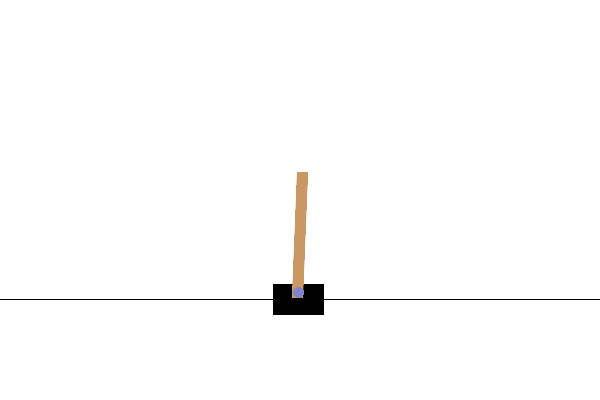

In [3]:
frames = []
for _ in range(200):
    inputs = env.sample_random_inputs()
    outputs = env.step(inputs)
    frames.append(PILImage.fromarray(env.render()[0]))
    print(inputs[0])
    print(outputs[0])

video_buffer = io.BytesIO()
frames[0].save(
    video_buffer,
    format="GIF",
    save_all=True,
    append_images=frames[1:],
    duration=50,
    loop=0,
)
display(Image(data=video_buffer.getvalue()))

## Inspect specs

`input_specs` and `output_specs` describe the full contract before any steps. Use them to allocate buffers, build network heads, or validate shapes.

In [4]:
ispec = env.input_specs[0]
ospec = env.output_specs[0]

print("Input spec:")
print(f"  action  dtype={ispec.action.dtype}  shape={ispec.action.shape}")
print()
print("Output spec:")
print(f"  observation  dtype={ospec.observation.dtype}  shape={ospec.observation.shape}")
print(f"  reward       dtype={ospec.reward.dtype}        shape={ospec.reward.shape}")
print(f"  done         dtype={ospec.done.dtype}          shape={ospec.done.shape}")
print(f"  time         dtype={ospec.time.dtype}          shape={ospec.time.shape}")
print(f"  q_star       {ospec.q_star}  (None = not configured)")

Input spec:
  action  dtype=torch.int64  shape=()

Output spec:
  observation  dtype=torch.float32  shape=(4,)
  reward       dtype=torch.float32        shape=()
  done         dtype=torch.int64          shape=()
  time         dtype=torch.int64          shape=()
  q_star       None  (None = not configured)


## Cleanup

In [5]:
env.close()